# CartPole DQN – Optimizado con Optuna y TensorBoard

Flujo de trabajo:
1. Búsqueda de hiperparámetros con **Optuna**
2. Entrenamiento final con **TensorBoard** en tiempo real
3. Grabación de vídeo y curva de aprendizaje

In [1]:
# Cell 1 – Imports
import os, random, base64
from pathlib import Path

import numpy as np
import torch as th
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import (
    EvalCallback, CallbackList, StopTrainingOnRewardThreshold
)
from stable_baselines3.common.vec_env import VecVideoRecorder, DummyVecEnv

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from optuna.visualization import (
    plot_optimization_history, plot_param_importances, plot_contour
)
from IPython import display as ipythondisplay

print('All imports OK')

C:\Users\aduo\.conda\envs\EU4DUAL\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK


In [2]:
# Cell 2 – Config, seeds & paths
SEED = 42
np.random.seed(SEED); th.manual_seed(SEED); random.seed(SEED)
if th.cuda.is_available():
    th.cuda.manual_seed_all(SEED)
th.set_num_threads(1)   # faster CPU inference during evaluation

# Optuna settings
N_TRIALS         = 2
N_JOBS           = 2
N_STARTUP_TRIALS = 5
N_EVALUATIONS    = 2
N_TIMESTEPS      = 100_000
TIMEOUT          = 60 * 30     # 30 min wall-clock budget

# Directories
LOG_DIR = './train_logs/'
TB_DIR  = './tensorboard_logs/'
MDL_DIR = './model/'
VID_DIR = './videos/'
DB_PATH = 'sqlite:///DQN_cartpole.db'
STUDY   = 'cartpole_dqn_v3'
for d in [LOG_DIR, TB_DIR, MDL_DIR, VID_DIR]:
    os.makedirs(d, exist_ok=True)

# Device
DEVICE = 'cuda' if th.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if th.cuda.is_available():
    print(f'GPU    : {th.cuda.get_device_name(0)}')

# Default DQN kwargs shared across all Optuna trials
DEFAULT_HPS = dict(
    policy='MlpPolicy',
    verbose=0,
    device=DEVICE,
    learning_starts=1_000,
    seed=SEED,
)

Device : cpu


In [3]:
# Cell 3 – Hyperparameter search space
def sample_dqn_params(trial: optuna.Trial) -> dict:
    """Sample DQN hyperparameters for CartPole-v1."""
    lr       = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    buf      = trial.suggest_categorical('buffer_size', [5_000, 10_000, 50_000])
    bs       = trial.suggest_categorical('batch_size', [64, 128, 256])
    eps_frac = trial.suggest_float('exploration_fraction', 0.2, 0.7)
    eps_fin  = trial.suggest_float('exploration_final_eps', 0.005, 0.05)
    tui      = trial.suggest_categorical(
        'target_update_interval', [25, 50, 100, 250, 500]
    )
    gamma    = trial.suggest_float('gamma', 0.9, 0.999)
    arch_str = trial.suggest_categorical('net_arch', ['64_64', '128_128', '256_256'])
    net_arch = [int(x) for x in arch_str.split('_')]

    return dict(
        learning_rate=lr,
        buffer_size=buf,
        batch_size=bs,
        exploration_fraction=eps_frac,
        exploration_final_eps=eps_fin,
        target_update_interval=tui,
        gamma=gamma,
        policy_kwargs=dict(net_arch=net_arch),
    )

In [4]:
# Cell 4 – Unified TrialEvalCallback (trial=None → final mode, no pruning)
class TrialEvalCallback(EvalCallback):
    """EvalCallback with optional Optuna pruning and optional reward-threshold stopping.

    - Pass ``trial`` during Optuna search to enable pruning.
    - Pass ``reward_threshold`` during final training to stop early once reached.
    """

    def __init__(self, eval_env, trial=None, n_eval_episodes=5,
                 eval_freq=10_000, deterministic=True, verbose=0,
                 reward_threshold=None):
        super().__init__(
            eval_env,
            n_eval_episodes=n_eval_episodes,
            eval_freq=eval_freq,
            deterministic=deterministic,
            verbose=verbose,
        )
        self.trial            = trial
        self.eval_idx         = 0
        self.is_pruned        = False
        self.reward_threshold = reward_threshold

    def _on_step(self) -> bool:
        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            super()._on_step()
            self.eval_idx += 1
            print(f'  [Eval {self.eval_idx:>3d}] mean_reward = {self.last_mean_reward:.2f}')

            # Optuna pruning (search phase)
            if self.trial is not None:
                self.trial.report(self.last_mean_reward, self.eval_idx)
                if self.trial.should_prune():
                    self.is_pruned = True
                    return False

            # Early stopping on reward threshold (final training phase)
            if self.reward_threshold is not None and self.best_mean_reward >= self.reward_threshold:
                if self.verbose >= 1:
                    print(f'Stopping training because mean reward '
                          f'{self.best_mean_reward:.2f} >= threshold {self.reward_threshold}')
                return False
        return True

In [5]:
# Cell 5 – Optuna objective
def objective(trial: optuna.Trial) -> float:
    train_env = Monitor(gym.make('CartPole-v1', render_mode='rgb_array'))
    eval_env  = gym.make('CartPole-v1', render_mode='rgb_array')

    kwargs = {**DEFAULT_HPS, 'env': train_env}
    kwargs.update(sample_dqn_params(trial))

    model = DQN(**kwargs)
    cb = TrialEvalCallback(
        eval_env, trial,
        n_eval_episodes=5, eval_freq=5_000, verbose=0,
    )

    nan_hit = False
    try:
        model.learn(total_timesteps=N_TIMESTEPS, callback=cb)
    except AssertionError as e:
        print(e)
        nan_hit = True
    finally:
        model.env.close()
        eval_env.close()

    if nan_hit:        return float('nan')
    if cb.is_pruned:   raise optuna.exceptions.TrialPruned()
    return cb.last_mean_reward

In [ ]:
# Cell 6 – Run Optuna search
sampler = TPESampler(n_startup_trials=N_STARTUP_TRIALS, seed=SEED)
pruner  = MedianPruner(
    n_startup_trials=N_STARTUP_TRIALS,
    n_warmup_steps=N_EVALUATIONS // 3,
)
study = optuna.create_study(
    sampler=sampler, pruner=pruner, direction='maximize',
    storage=DB_PATH, study_name=STUDY, load_if_exists=True,
)

try:
    study.optimize(
        objective,
        n_trials=N_TRIALS,
        n_jobs=N_JOBS,
        timeout=TIMEOUT,
        show_progress_bar=True,
    )
except KeyboardInterrupt:
    print('Interrupted – using best trial so far.')

print(f'Finished trials : {len(study.trials)}')
print(f'Best value      : {study.best_trial.value:.2f}')
for k, v in study.best_trial.params.items():
    print(f'  {k}: {v}')

In [ ]:
# Cell 7a – Optuna: optimization history
plot_optimization_history(study).show()

In [ ]:
# Cell 7b – Optuna: parameter importances
plot_param_importances(study).show()

In [ ]:
# Cell 7c – Optuna: contour plot
plot_contour(study).show()

In [6]:
# Cell 8 – Load best trial & build final training kwargs
# (run this independently if the Optuna search ran in a previous session)
study = optuna.load_study(study_name=STUDY, storage=DB_PATH)
best  = study.best_trial
print(f'Best value : {best.value:.2f}')
for k, v in best.params.items():
    print(f'  {k}: {v}')

# Decode net_arch string back to a list
params = dict(best.params)
if 'net_arch' in params and isinstance(params['net_arch'], str):
    params['policy_kwargs'] = {
        'net_arch': [int(x) for x in params.pop('net_arch').split('_')]
    }

train_env = Monitor(gym.make('CartPole-v1', render_mode='rgb_array'), LOG_DIR)

final_kwargs = {
    **DEFAULT_HPS,
    'env'             : train_env,
    'verbose'         : 0,
    'tensorboard_log' : TB_DIR,    # <-- activates TensorBoard logging
}
final_kwargs.update(params)

import pprint
pprint.pprint(final_kwargs)

Best value : 146.20
  learning_rate: 0.000255463801770536
  buffer_size: 50000
  batch_size: 128
  exploration_fraction: 0.3731492925830697
  exploration_final_eps: 0.027035574517774285
  target_update_interval: 250
  gamma: 0.9386782345624229
  net_arch: 128_128
{'batch_size': 128,
 'buffer_size': 50000,
 'device': 'cpu',
 'env': <Monitor<TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>>>,
 'exploration_final_eps': 0.027035574517774285,
 'exploration_fraction': 0.3731492925830697,
 'gamma': 0.9386782345624229,
 'learning_rate': 0.000255463801770536,
 'learning_starts': 1000,
 'policy': 'MlpPolicy',
 'policy_kwargs': {'net_arch': [128, 128]},
 'seed': 42,
 'target_update_interval': 250,
 'tensorboard_log': './tensorboard_logs/',
 'verbose': 0}


## TensorBoard – monitoreo en tiempo real

Ejecuta **esta celda antes de entrenar** para abrir TensorBoard inline.
Las métricas (`ep_rew_mean`, `loss`, `exploration_rate` …) se actualizan cada 5 s.

> **Alternativa:** ejecuta `tensorboard --logdir ./tensorboard_logs/` en un terminal y abre http://localhost:6006

In [7]:
# Cell 9 – Launch TensorBoard (run BEFORE starting training)
import os, sys
_scripts = os.path.join(sys.prefix, 'Scripts')   # e.g. …/EU4DUAL/Scripts\n",
if _scripts not in os.environ.get('PATH', ''):
    os.environ['PATH'] = _scripts + os.pathsep + os.environ.get('PATH', '')

_tb_bin = os.path.join(_scripts, 'tensorboard.exe')
if os.path.isfile(_tb_bin):
    os.environ['TENSORBOARD_BINARY'] = _tb_bin
%load_ext tensorboard
%tensorboard --logdir ./tensorboard_logs/ --reload_interval 5

Reusing TensorBoard on port 6006 (pid 24096), started 0:26:04 ago. (Use '!kill 24096' to kill it.)

In [8]:
# Cell 10 – Final training with best hyperparameters
N_FINAL = 700_000

eval_env = gym.make('CartPole-v1', render_mode='rgb_array')

eval_cb  = TrialEvalCallback(
    eval_env,
    trial=None,               # no pruning during final training
    n_eval_episodes=10,
    eval_freq=5_000,
    verbose=0,
    reward_threshold=490,     # ← stop early once this mean reward is reached
)

model = DQN(**final_kwargs)
model.learn(
    total_timesteps=N_FINAL,
    callback=eval_cb,
    tb_log_name='DQN_cartpole_best',
    progress_bar=False,
)

model.save(os.path.join(MDL_DIR, 'DQN_cartpole_best.zip'))
print('Model saved.')

C:\Users\aduo\.conda\envs\EU4DUAL\Lib\site-packages\stable_baselines3\common\evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


  [Eval   1] mean_reward = 274.50
  [Eval   2] mean_reward = 185.10
  [Eval   3] mean_reward = 159.40
  [Eval   4] mean_reward = 153.70
  [Eval   5] mean_reward = 136.90
  [Eval   6] mean_reward = 117.10
  [Eval   7] mean_reward = 74.00
  [Eval   8] mean_reward = 113.00
  [Eval   9] mean_reward = 87.60
  [Eval  10] mean_reward = 77.50
  [Eval  11] mean_reward = 79.60
  [Eval  12] mean_reward = 59.80
  [Eval  13] mean_reward = 95.70
  [Eval  14] mean_reward = 109.90
  [Eval  15] mean_reward = 100.50
  [Eval  16] mean_reward = 63.30
  [Eval  17] mean_reward = 81.50
  [Eval  18] mean_reward = 91.70
  [Eval  19] mean_reward = 89.20
  [Eval  20] mean_reward = 113.30
  [Eval  21] mean_reward = 125.30
  [Eval  22] mean_reward = 117.70
  [Eval  23] mean_reward = 117.60
  [Eval  24] mean_reward = 104.20
  [Eval  25] mean_reward = 113.50
  [Eval  26] mean_reward = 100.20
  [Eval  27] mean_reward = 108.60
  [Eval  28] mean_reward = 118.00
  [Eval  29] mean_reward = 93.90
  [Eval  30] mean_reward 

In [9]:
# Cell 11 – Video recording helpers
def record_video(env_id='CartPole-v1', model=None, video_length=500,
                 prefix='', video_folder='videos/'):
    """Record one episode of the trained agent."""
    e = DummyVecEnv([lambda: gym.make(env_id, render_mode='rgb_array')])
    if hasattr(e, 'envs') and e.envs and hasattr(e.envs[0], 'metadata'):
        e.envs[0].metadata['render_fps'] = 30
    e = VecVideoRecorder(
        e, video_folder=video_folder,
        record_video_trigger=lambda s: s == 0,
        video_length=video_length, name_prefix=prefix,
    )
    obs = e.reset()
    for _ in range(video_length):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, _, _ = e.step(action)
    e.close()


def show_videos(video_path='', prefix=''):
    """Display mp4 videos whose filename starts with *prefix*."""
    html = []
    for mp4 in Path(video_path).glob(f'{prefix}*.mp4'):
        b64 = base64.b64encode(mp4.read_bytes()).decode('ascii')
        html.append(
            f'<video autoplay loop controls style="height:400px;">'
            f'<source src="data:video/mp4;base64,{b64}" type="video/mp4"/>'
            f'</video>'
        )
    ipythondisplay.display(ipythondisplay.HTML('<br>'.join(html)))

In [14]:
# Cell 12 – Record and show the trained agent
record_video('CartPole-v1', model, video_length=1_000,
             prefix='cartpole_best', video_folder=VID_DIR)
show_videos(VID_DIR, prefix='cartpole_best')

Saving video to C:\Users\aduo\MGEP Dropbox\H - Hezkuntza Arautua\Koord_Masterra\M2MT - Inteligencia Artificial\5_Internazionala\2526_EU4DUAL_ReinforcementLearning\Course_notebooks\videos\cartpole_best-step-0-to-step-1000.mp4
MoviePy - Building video C:\Users\aduo\MGEP Dropbox\H - Hezkuntza Arautua\Koord_Masterra\M2MT - Inteligencia Artificial\5_Internazionala\2526_EU4DUAL_ReinforcementLearning\Course_notebooks\videos\cartpole_best-step-0-to-step-1000.mp4.
MoviePy - Writing video C:\Users\aduo\MGEP Dropbox\H - Hezkuntza Arautua\Koord_Masterra\M2MT - Inteligencia Artificial\5_Internazionala\2526_EU4DUAL_ReinforcementLearning\Course_notebooks\videos\cartpole_best-step-0-to-step-1000.mp4



MoviePy - Done !
MoviePy - video ready C:\Users\aduo\MGEP Dropbox\H - Hezkuntza Arautua\Koord_Masterra\M2MT - Inteligencia Artificial\5_Internazionala\2526_EU4DUAL_ReinforcementLearning\Course_notebooks\videos\cartpole_best-step-0-to-step-1000.mp4


In [13]:
!pip install gymnasium[other]

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------------------- -------------------- 3.4/7.0 MB 16.8 MB/s eta 0:00:01
   ---------------------------------------  6.8/7.0 MB 17.5 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 14.8 MB/s  0:00:00
   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   ---- ----------------------------------- 3.7/31.2 MB 18.1 MB/s eta 0:00:02
   --------- ------------------------------ 7.1/31.2 MB 18.2 MB/s eta 0:00:02
   ------------- -------------------------- 10.7/31.2 MB 17.7 MB/s eta 0:00:02
   ------------------ --------------------- 14.2/31.2 MB 17.1 MB/s eta 0:00:02
   ---------------------- ----------------- 17.6/31.2 MB 16.8 MB/s eta 0:00:01
   -------------------------- ------------- 21.0/31.2 MB 16.8 MB/s eta 0:00:01
   ------------------------------- -------- 24.4/31.2 MB 16.8 MB/s eta 0:00:01
   --------------

  You can safely remove it manually.


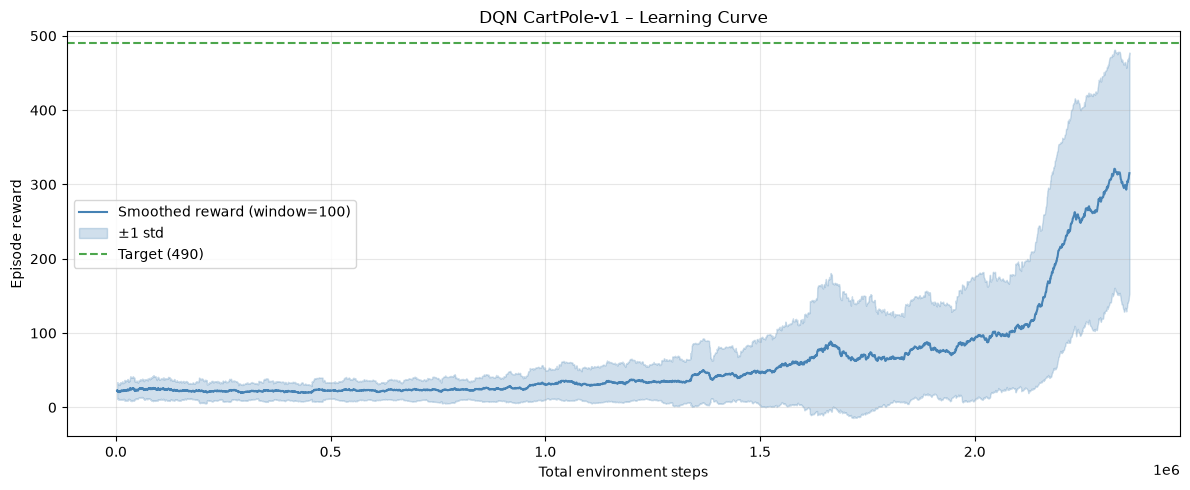

In [15]:
# Cell 13 – Learning curve from Monitor logs
data = pd.read_csv(os.path.join(LOG_DIR, 'monitor.csv'), skiprows=1)
data.columns = ['reward', 'length', 'timestep']

W  = 100
sm = data['reward'].rolling(W).mean()
sd = data['reward'].rolling(W).std()
cx = data['timestep'].cumsum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cx, sm, color='steelblue', label=f'Smoothed reward (window={W})')
ax.fill_between(cx, sm - sd, sm + sd, alpha=0.25,
                color='steelblue', label='\u00b11 std')
ax.axhline(490, color='green', ls='--', alpha=0.7, label='Target (490)')
ax.set(xlabel='Total environment steps',
       ylabel='Episode reward',
       title='DQN CartPole-v1 \u2013 Learning Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MDL_DIR, 'learning_curve.png'), dpi=150)
plt.show()